In [36]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.5)

In [37]:
#n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 3, 0.5, 0.8, 1, 1, 0.1
n_states, start_width, response_width, delta, measurement_prob,  I, J, steps = 7, None, 1, 0.5, 0.8, 1, 1, 0.1
start_width = (n_states-2*response_width)-2 #(n_states-2*response_width)//2 #

m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")
n_states, start_width, response_width

(7, 3, 1)

In [38]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100

#m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100
#q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[5]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [39]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [40]:
ca._get_transition_matrix(intensity_matrix_markov, RT=delta, delta=delta, Mn=m_Mn, transition_type="RT").squeeze().round(decimals=2)

Array([[0.42, 0.1 , 0.01, 0.  , 0.  , 0.  , 0.  ],
       [0.4 , 0.45, 0.1 , 0.01, 0.  , 0.  , 0.  ],
       [0.15, 0.31, 0.44, 0.1 , 0.01, 0.  , 0.  ],
       [0.04, 0.11, 0.3 , 0.44, 0.1 , 0.01, 0.  ],
       [0.01, 0.03, 0.11, 0.3 , 0.44, 0.11, 0.05],
       [0.  , 0.01, 0.03, 0.12, 0.33, 0.55, 0.43],
       [0.  , 0.  , 0.01, 0.03, 0.11, 0.32, 0.52]], dtype=float64)

In [41]:
(np.abs(ca._get_transition_matrix(intensity_matrix_quantum, RT=delta, delta=delta, Mn=q_Mn, transition_type="RT").squeeze())**2).round(decimals=3)

array([[0.344, 0.493, 0.144, 0.017, 0.001, 0.   , 0.   ],
       [0.493, 0.042, 0.327, 0.121, 0.016, 0.001, 0.   ],
       [0.144, 0.327, 0.056, 0.334, 0.121, 0.016, 0.001],
       [0.017, 0.121, 0.334, 0.056, 0.334, 0.121, 0.017],
       [0.001, 0.016, 0.121, 0.334, 0.056, 0.327, 0.144],
       [0.   , 0.001, 0.016, 0.121, 0.327, 0.042, 0.493],
       [0.   , 0.   , 0.001, 0.017, 0.144, 0.493, 0.344]])

<Axes: >

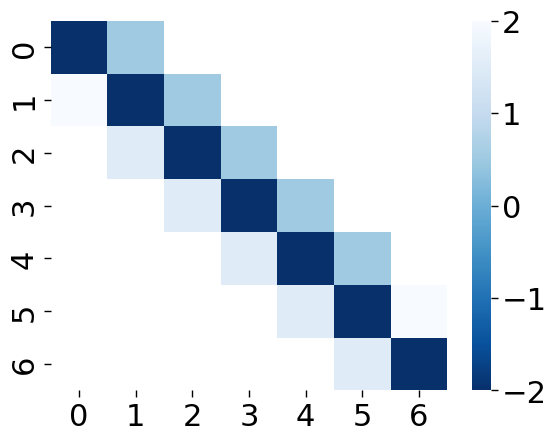

In [42]:

sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) , cmap = "Blues_r")

In [43]:
np.imag(np.where(intensity_matrix_quantum.squeeze()==0,np.nan,intensity_matrix_quantum.squeeze()) )

array([[ 3., -2.,  0.,  0.,  0.,  0.,  0.],
       [-2.,  2., -2.,  0.,  0.,  0.,  0.],
       [ 0., -2.,  1., -2.,  0.,  0.,  0.],
       [ 0.,  0., -2.,  0., -2.,  0.,  0.],
       [ 0.,  0.,  0., -2., -1., -2.,  0.],
       [ 0.,  0.,  0.,  0., -2., -2., -2.],
       [ 0.,  0.,  0.,  0.,  0., -2., -3.]])

<Axes: >

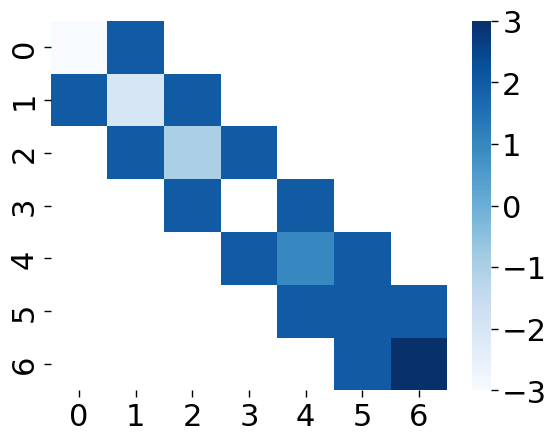

In [44]:
intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = "Blues")

In [45]:
phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.33333333],
          [0.33333333],
          [0.33333333]]]], dtype=float64),
 Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.57735027],
          [0.57735027],
          [0.57735027]]]], dtype=float64))

In [46]:
phi_0_markov

Array([[[[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.33333333],
         [0.33333333],
         [0.33333333]]]], dtype=float64)

In [47]:
ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[0.5]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

Array([[[[2.18466111e-05],
         [3.60961755e-04],
         [4.50644189e-03],
         [3.92803048e-02],
         [2.00812168e-01],
         [4.37802853e-01],
         [3.17215424e-01]]]], dtype=float64)

phi_0_quantum = npx.array([[[[0.06871463],
         [0.07356508],
         [0.08124495],
         [0.10388036],
         [0.12732417],
         [0.11843169],
         [0.10549717],
         [0.09700889],
         [0.08124495],
         [0.06911884],
         [0.07396928]]]])
phi_0_quantum.shape

In [48]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "All", "Lower", "Centered"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,10/delta,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,10/delta,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [49]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-3,Upper,0.0,0.08896683632464432,0.08922065141958392
1,-2,Upper,0.0,2.7755575615628914e-17,0.15534400244037774
2,-1,Upper,0.0,-0.047224997781078346,0.06612335102079386
3,0,Upper,0.0,0.15157959413999322,0.15476900391000412
4,1,Upper,0.0,0.13202083382321886,0.40323620851668823
...,...,...,...,...,...
1059,-1,Centered,3.7,-0.4140969650110367,0.14518493437790264
1060,0,Centered,3.7,-0.23082987483298503,0.37471707022423406
1061,1,Centered,3.7,-0.13757956328247872,0.22953213584633161
1062,2,Centered,3.7,0.17475985133557653,0.08880151861335939


In [50]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [51]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

intensity_matrix_markov

pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

In [52]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered"}))

with sns.plotting_context("talk",font_scale=1.2):
    f = sns.relplot(df_markov_plot
                    .query("time <= 6 and prior == 'Uniform'")
                    ,alpha=0.8,
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=2.3, height=4.3)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Confidence States")
    f.set(ylim=(-3.99, 3.99))

with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_markov_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()


with sns.plotting_context("talk",font_scale=1.2):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 20 and prior == 'Uniform'")
                    ,alpha=0.8,
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=2.3, height=4.3)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Confidence States")
    f.set(ylim=(-5.5, 5.5))

with sns.plotting_context("talk",font_scale=1.9):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 20 and prior == 'Uniform'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.3, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Conf States")
    #f.set(ylim=(-5.5, 5.5))


with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 15")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [53]:
df_plot = pd.concat([df_markov_plot.assign(type="Diffusion Random-Walk Model"), df_quantum_plot.assign(type="Quantum Random-Walk Model")])
df_plot

,states,prior,time,value,type
0,-3,+High,0.0,0.000000,Diffusion Random-Walk Model
1,-2,+High,0.0,0.000000,Diffusion Random-Walk Model
2,-1,+High,0.0,0.000000,Diffusion Random-Walk Model
3,0,+High,0.0,0.000000,Diffusion Random-Walk Model
4,1,+High,0.0,0.333333,Diffusion Random-Walk Model
...,...,...,...,...,...
1087,-1,Centered,19.0,0.192555,Quantum Random-Walk Model
1088,0,Centered,19.0,0.193695,Quantum Random-Walk Model
1089,1,Centered,19.0,0.071613,Quantum Random-Walk Model
1090,2,Centered,19.0,0.038427,Quantum Random-Walk Model


with sns.plotting_context(font_scale=1):
    f = sns.relplot(df_plot
                    .query("time <= 20 ")
                    ,alpha=0.8, row="type", col="prior", sizes=(40,700), 
    x="time", y="states",size="value", color="Black", aspect=2, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

df_plot

In [54]:
df_plot.query("prior == 'Centered' and time <= 8 ")

,states,prior,time,value,type
21,-3,Centered,0.0,0.000000,Diffusion Random-Walk Model
22,-2,Centered,0.0,0.000000,Diffusion Random-Walk Model
23,-1,Centered,0.0,0.333333,Diffusion Random-Walk Model
24,0,Centered,0.0,0.333333,Diffusion Random-Walk Model
25,1,Centered,0.0,0.333333,Diffusion Random-Walk Model
...,...,...,...,...,...
471,-1,Centered,8.0,0.163759,Quantum Random-Walk Model
472,0,Centered,8.0,0.349032,Quantum Random-Walk Model
473,1,Centered,8.0,0.154395,Quantum Random-Walk Model
474,2,Centered,8.0,0.008682,Quantum Random-Walk Model


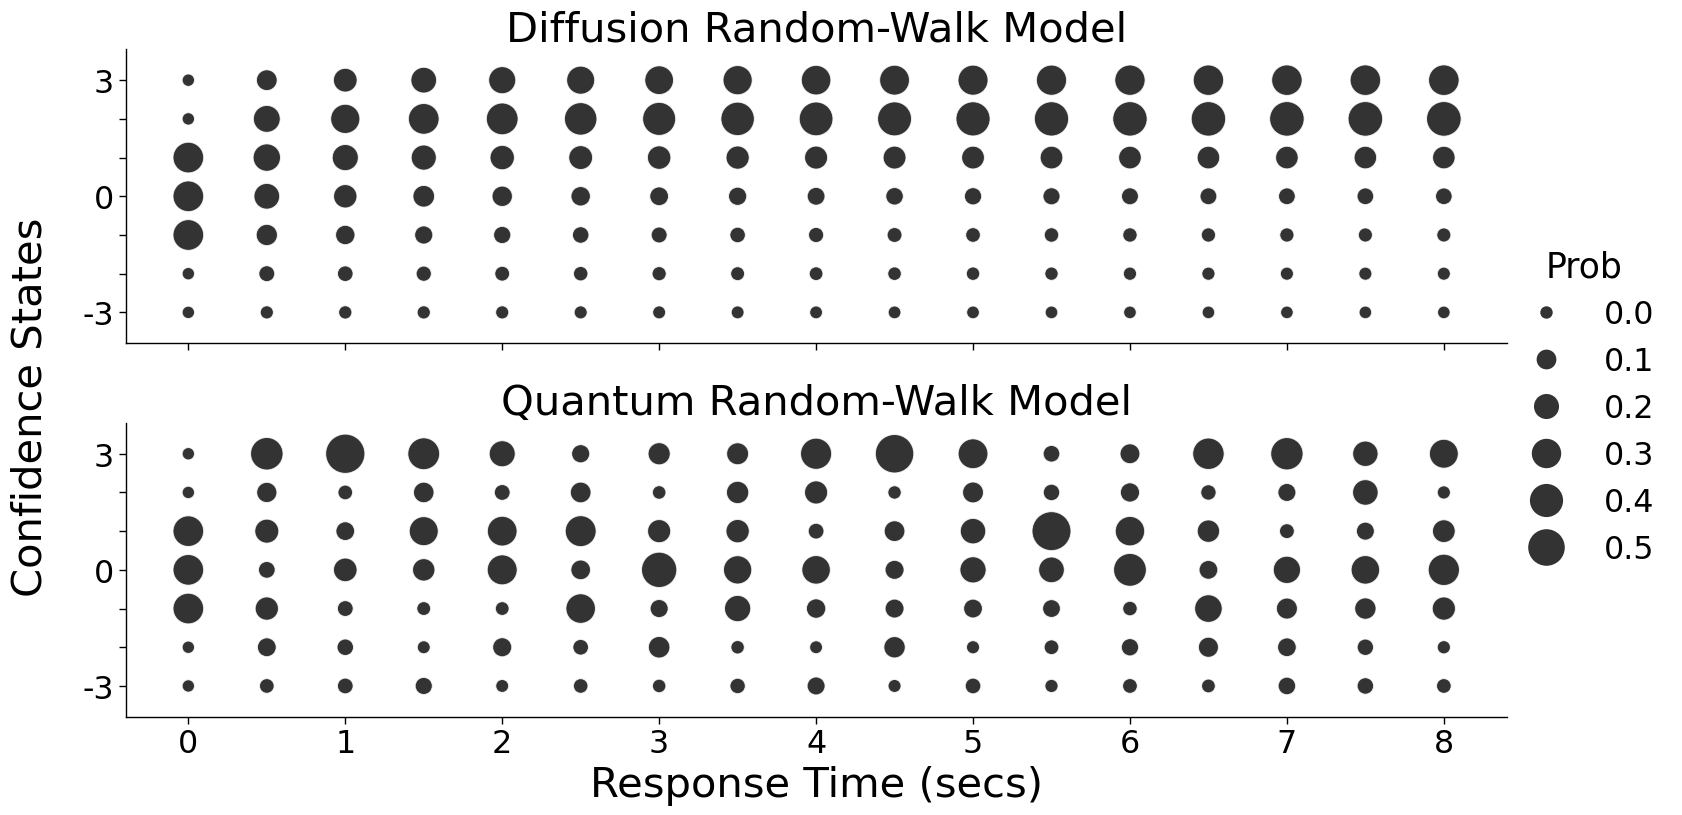

In [55]:
with sns.plotting_context("paper",font_scale=2.6):
    f = sns.relplot(df_plot
                    .query("prior == 'Centered' and time <= 8 ")
                    ,alpha=0.8, col="type", col_wrap=1, sizes=(80,800), 
    x="time", y="states",size="value", color="Black", aspect=3.6, height=4.3)
    f.set_titles("{col_name}", size=30)
    f.legend.set_title("Prob")
    f.set_xlabels("Response Time (secs)", fontsize=30)
    f.set_ylabels("")
    f.figure.supylabel("Confidence States", fontsize=30)
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.8, 3.8))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [56]:
import matplotlib as mpl
mpl.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [57]:
mid = int(n_states+1)/2

states_ticks = np.arange(-(mid-1), mid)
states_labels = (states_ticks + (5 * np.sign(states_ticks))) * 10
states_labels

array([-80., -70., -60.,   0.,  60.,  70.,  80.])

df_quantum_plot.groupby(["time", "prior"], sort=False)[["value", "states"]].apply(lambda df: df.value * df.states)#.values

def test(df):
    #print((df.value * df.state_labels).values.shape)
    return (df.value * df.state_labels).values
df_quantum_plot.query("prior=='Uniform' and time < 15") \
.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ) \
.assign(mean_conf = lambda df: df.groupby(["time", "prior"], sort=False)[["value", "state_labels"]].apply(lambda df: df.value * df.state_labels).values)

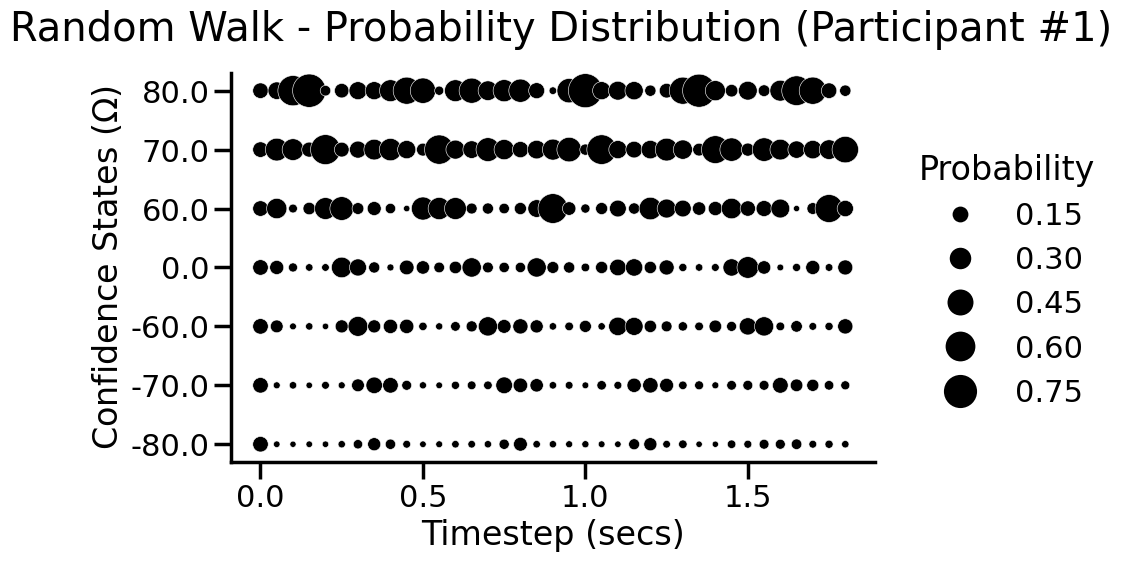

In [58]:
with sns.plotting_context(context="poster"):
    f = sns.relplot(df_quantum_plot.query("prior=='All' and time < 18.24").assign(time = lambda df: df.time * 0.1), 
    x="time", y="states",size="value", legend=True, sizes=(20,600), aspect=1.5, color="black", height=5.5 )
    f.set(yticks = states_ticks)
    f.set_yticklabels(labels=states_labels)
    f.set_ylabels(r"Confidence States $(\Omega)$")
    f.set_xlabels("Timestep (secs)")
    f.legend.set_title("Probability")
    f.figure.suptitle("Random Walk - Probability Distribution (Participant #1)", y=1.05)


fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

f = sns.relplot(df_quantum_plot.astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, height = 4.5)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [59]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [60]:
start_width

3

In [61]:
steps=0.01
delta=steps

In [62]:
n_states, start_width, response_width,

(7, 3, 1)

In [63]:
m_sigma, q_sigma

(Array([[2]], dtype=int64), Array([[2]], dtype=int64))

n_states, start_width, response_width = 11, 5 ,2
#mv = np.asarray([-100,-90,-80,-70,-60, 0, 60, 70, 80,90,100])
start_width = (n_states-2*response_width)-2
mv = np.arange(-(n_states//2), (n_states//2)+1)

start_width

In [64]:
n_states, (start_width:=3), response_width, (measurement_prob:=0.8), (steps := 0.01), (delta := 0.01) # configuration used for publication

(7, 3, 1, 0.8, 0.01, 0.01)

In [65]:
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = "Quantum")

In [74]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

df_markov_internal_1 = pd.DataFrame()
df_quantum_internal_1 = pd.DataFrame()

for mu in [npx.asarray([[1]])]:#, npx.asarray([[-0.05]]), npx.asarray([[1]]), npx.asarray([[-1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_markov_i = dd._buildK(n_states, mu, m_sigma, boundary_type="Internal")
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    #print(intensity_matrix_markov)
    prior_types = ["Upper", "Centered"] #"Lower", 
    for prior_type in prior_types: #, "Opposite"
        phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []

        phi_markov_internal_arr = []
        phi_quantum_internal_arr = []

        #phi_markov_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)

        #phi_markov_internal_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_internal_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)

        timesteps = np.arange(steps*2,20,steps)
        for t in timesteps:
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_internal = ca.perform_state_transition(intensity_matrix_markov_i, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
            phi_markov_internal_arr.append(np.asarray(phi_markov_internal.squeeze() @ mv))

        for t in timesteps:
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_internal = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
            phi_quantum_internal_arr.append((np.abs(phi_quantum_internal.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T])

        df_markov_internal_1 = pd.concat([df_markov_internal_1, pd.DataFrame(phi_markov_internal_arr).T])
        df_quantum_internal_1 = pd.concat([df_quantum_internal_1, pd.DataFrame(phi_quantum_internal_arr).T])


df_markov1 = df_markov1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum1 = df_quantum1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")
df_markov_internal_1 = df_markov_internal_1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum_internal_1 = df_quantum_internal_1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")

phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type="Upper")
phi_quantum_internal = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[0.02]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
(np.abs(phi_quantum_internal.squeeze())**2) @ mv

In [75]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))

df_markov1_internal_plot = df_markov_internal_1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_internal_plot = df_quantum_internal_1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))

df_markov1_plot.query("value > 3")

,prior,mu,time,value


df_markov1_internal_plot

with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_markov1_internal_plot.query("time < 8 and mu == '$v$=1, $\sigma$=2'"), x="time", y="value", 
                    style="prior", color="black", aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.ax.set_title('$v$=1, $\sigma$=2')
    #f.set_titles("{col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Confidence States")
    #f.set(yticks=[-3,-2,-1,0,1,2,3])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Diffusion Random-Walk Model", y = 1.08)

with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(18,5), sharey=True)

    #f = sns.lineplot(df_markov1_plot.query("time < 40"), x="time", y="value", 
    #                hue="prior", ax=axs, lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    sns.lineplot(df_quantum1_plot.query("time < 40 and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[1], lw=3, label="Externally Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 40 and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[1], lw=3, label="Internal Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)

    sns.lineplot(df_markov1_plot.query("time < 40  and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[0], lw=3, label="External Controlled")

    f = sns.lineplot(df_markov1_internal_plot.query("time < 40  and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[0], lw=3, label="Internal Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="", title_fontsize=23, fontsize=21)
    axs[0].set_title('Diffusion')
    axs[1].set_title('Quantum')
    #f.set_titles("{col_name}")
    axs[0].figure.supxlabel("Response Time (secs)", y=-0.1)
    axs[0].set_xlabel("")
    axs[0].set_ylabel("")
    axs[1].set_xlabel("")
    axs[1].set_ylabel("")
    #f1.set_ylabel("")
    axs[1].get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["Incorrect","","","0","","","Correct"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["Incorrect","","","0","","","Correct"])
    #f.figure.suptitle(f"Mean Confidence State", y = 1.08)
sns.despine()

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like

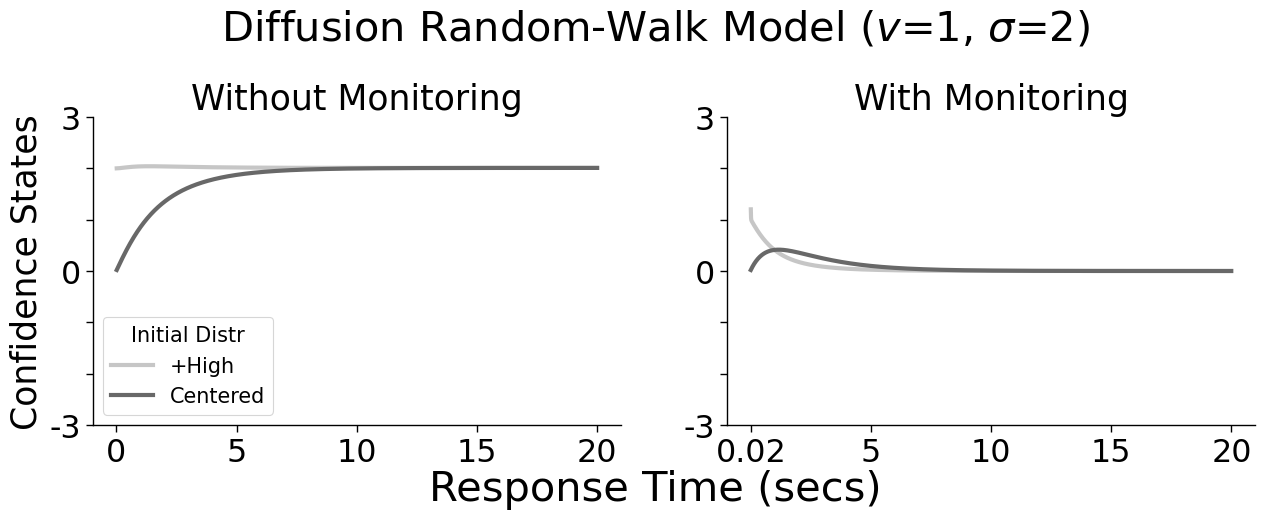

In [87]:
with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(15,4))

    f = sns.lineplot(df_markov1_plot.query("time < 20  and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_markov1_internal_plot.query("time < 20  and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[1], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    f.set_title('Without Monitoring')
    f1.set_title('With Monitoring')
    #f.set_titles("{col_name}")
    f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f.set_xlabel("")
    f1.set_xlabel("")
    f.set_ylabel("Confidence States")
    f1.set_ylabel("")
    f1.get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["-3","","","0","","","3"])
    #f1.set_xlim(2*steps, None)
    f1.set(xticks = [2*steps, 5, 10, 15, 20])
    f1.set_xticklabels([str(2*steps),"5","10","15","20"])
    f.figure.suptitle(f"Diffusion Random-Walk Model ($v$=1, $\sigma$={m_sigma[0][0]})", y = 1.15)
sns.despine()

with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_quantum1_internal_plot.query("time <= 8 and mu == '$v$=1, $\sigma$=2'"), x="time", y="value", 
                    style="prior", col="mu", color="black", aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.set_titles("{col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Confidence States")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Quantum Random-Walk Model", y = 1.05)

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



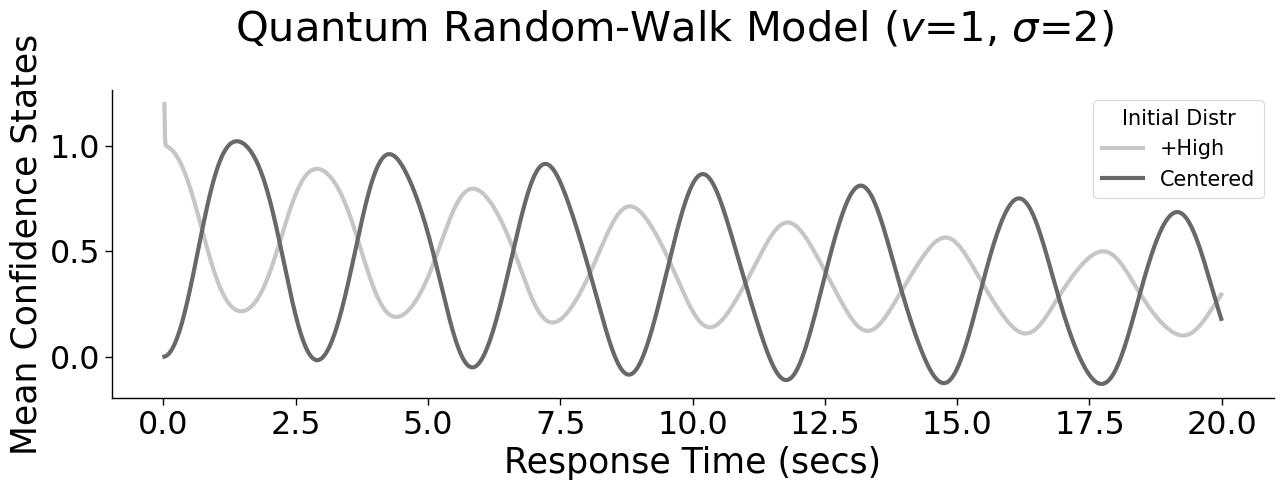

In [77]:
with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,1,figsize=(15,4))

    #f = sns.lineplot(df_quantum1_plot.query("time < 20"), x="time", y="value", 
    #                hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 40 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs, lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f1.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    #f.set_title('External')
    #f1.set_title('Internal')
    #f.set_titles("{col_name}")
    #f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f1.set_xlabel("Response Time (secs)")
    f1.set_ylabel("Mean Confidence States")
    #f1.set(yticks=[-3,-2,-1,0,1,2,3])
    #f1.set_yticklabels(["-3","","","0","","","3"])
    f1.figure.suptitle(f"Quantum Random-Walk Model ($v$=1, $\sigma$={q_sigma[0][0]})", y = 1.08)
sns.despine()

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like

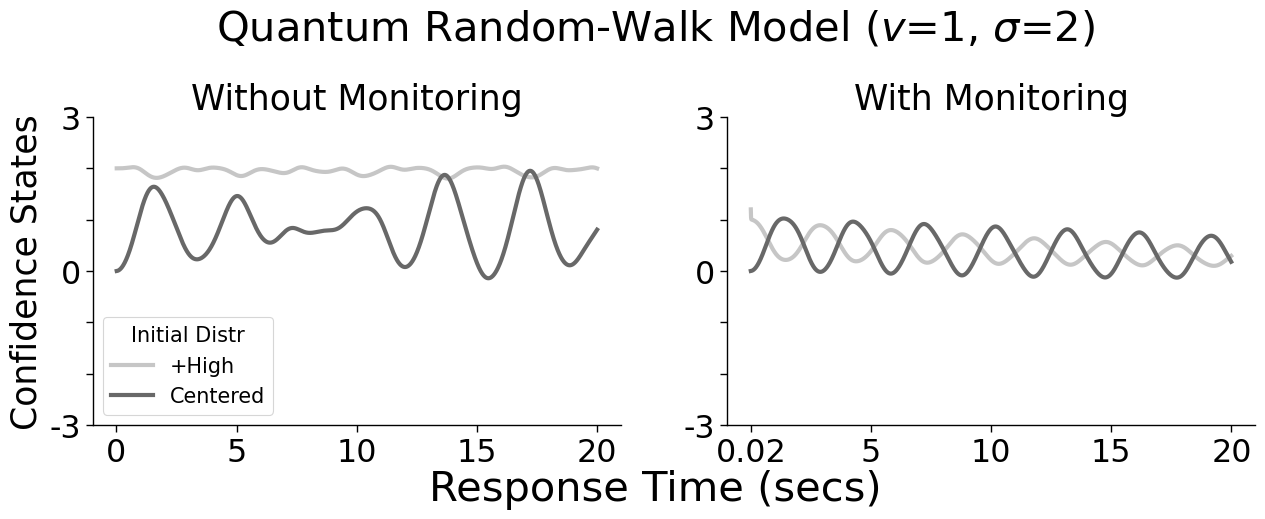

In [86]:
with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(15,4))

    f = sns.lineplot(df_quantum1_plot.query("time < 20 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 20 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[1], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    f.set_title('Without Monitoring')
    f1.set_title('With Monitoring')
    #f.set_titles("{col_name}")
    f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f.set_xlabel("")
    f1.set_xlabel("")
    f.set_ylabel("Confidence States")
    f1.set_ylabel("")
    f1.get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["-3","","","0","","","3"])
    f1.set(xticks = [2*steps, 5, 10, 15, 20])
    f1.set_xticklabels([str(2*steps),"5","10","15","20"])

    f.figure.suptitle(f"Quantum Random-Walk Model ($v$=1, $\sigma$={q_sigma[0][0]})", y = 1.15)
sns.despine()

In [89]:
df_plot1 = pd.concat([df_quantum1_plot.assign(type="Quantum"), df_markov1_plot.assign(type="Diffusion")])
df_plot1

,prior,mu,time,value,type
0,+High,"$v$=1, $\sigma$=2",0.0,2.499900,Quantum
1,-High,"$v$=1, $\sigma$=2",0.0,-2.499700,Quantum
2,Centered,"$v$=1, $\sigma$=2",0.0,0.500100,Quantum
3,+High,"$v$=1, $\sigma$=2",0.01,2.499600,Quantum
4,-High,"$v$=1, $\sigma$=2",0.01,-2.498800,Quantum
...,...,...,...,...,...
5992,-High,"$v$=1, $\sigma$=2",19.97,2.007921,Diffusion
5993,Centered,"$v$=1, $\sigma$=2",19.97,2.008206,Diffusion
5994,+High,"$v$=1, $\sigma$=2",19.98,2.008254,Diffusion
5995,-High,"$v$=1, $\sigma$=2",19.98,2.007922,Diffusion


In [90]:
df_plot_internal1 = pd.concat([df_quantum1_internal_plot.assign(type="Quantum"), df_markov1_internal_plot.assign(type="Diffusion")])
df_plot_internal1

,prior,mu,time,value,type
0,+High,"$v$=1, $\sigma$=2",0.0,2.499900,Quantum
1,-High,"$v$=1, $\sigma$=2",0.0,-2.499700,Quantum
2,Centered,"$v$=1, $\sigma$=2",0.0,0.500100,Quantum
3,+High,"$v$=1, $\sigma$=2",0.01,1.299354,Quantum
4,-High,"$v$=1, $\sigma$=2",0.01,-1.299366,Quantum
...,...,...,...,...,...
5992,-High,"$v$=1, $\sigma$=2",19.97,0.000043,Diffusion
5993,Centered,"$v$=1, $\sigma$=2",19.97,0.000043,Diffusion
5994,+High,"$v$=1, $\sigma$=2",19.98,0.000005,Diffusion
5995,-High,"$v$=1, $\sigma$=2",19.98,0.000043,Diffusion


In [91]:
custom_color = ["Green","Orange", "Red"]

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like

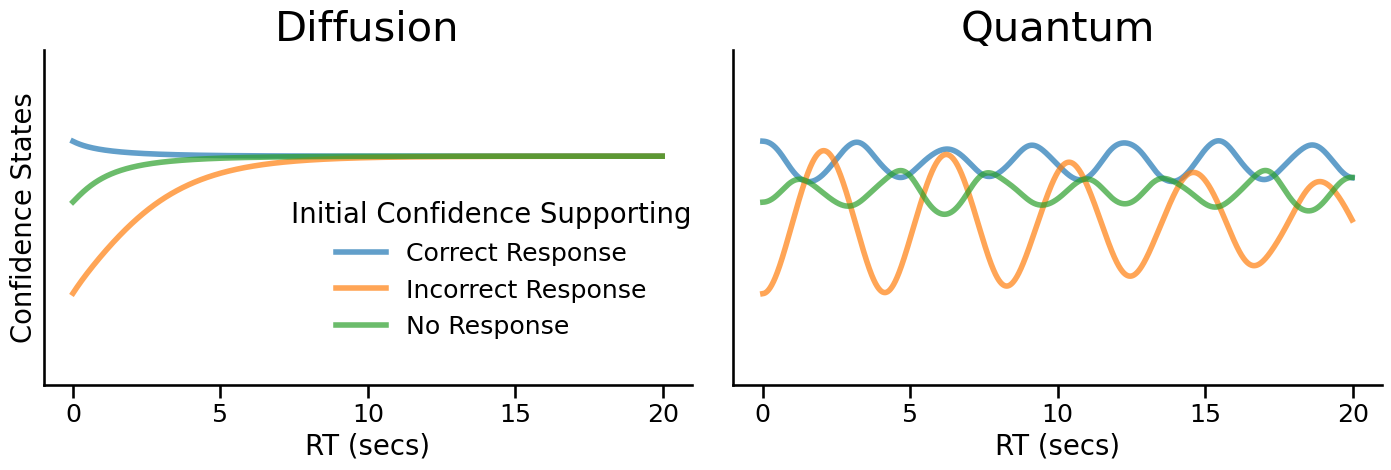

In [92]:
with sns.plotting_context("talk", font_scale=1.1):
    f = sns.relplot(df_plot1.query("(mu =='$v$=1, $\sigma$=2')").assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response", "Opposite":"Both Responses"})),
                     x="time", y="value", 
                    col_order=["Diffusion", "Quantum"], hue = "prior", #hue_order= ["Correct Response", "No Response" ,"Incorrect Response", "Both Responses"],
                    #palette=custom_color,
                    col="type", color="black", aspect=1.5, height=5, kind="line",lw=4, alpha=0.7)
    f.legend.set_title("Initial Confidence Supporting")
    f.legend.set_bbox_to_anchor((0.39,0.4))
    f.set_titles("{col_name}", size=30)
    f.set_xlabels("RT (secs)")
    #f.axes[1,0].set_ylabel("CS (Quantum)")
    #f.axes[1,0].set_title("")
    #f.axes[1,1].set_title("")
    #f.axes[1,2].set_title("")
    #f.axes[1,3].set_title("")
    #f.axes[0,0].set_ylabel("CS (Diffusion)")
    f.set(yticks=[])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-5.5, 5.5))
    f.set_ylabels("Confidence States")


/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like

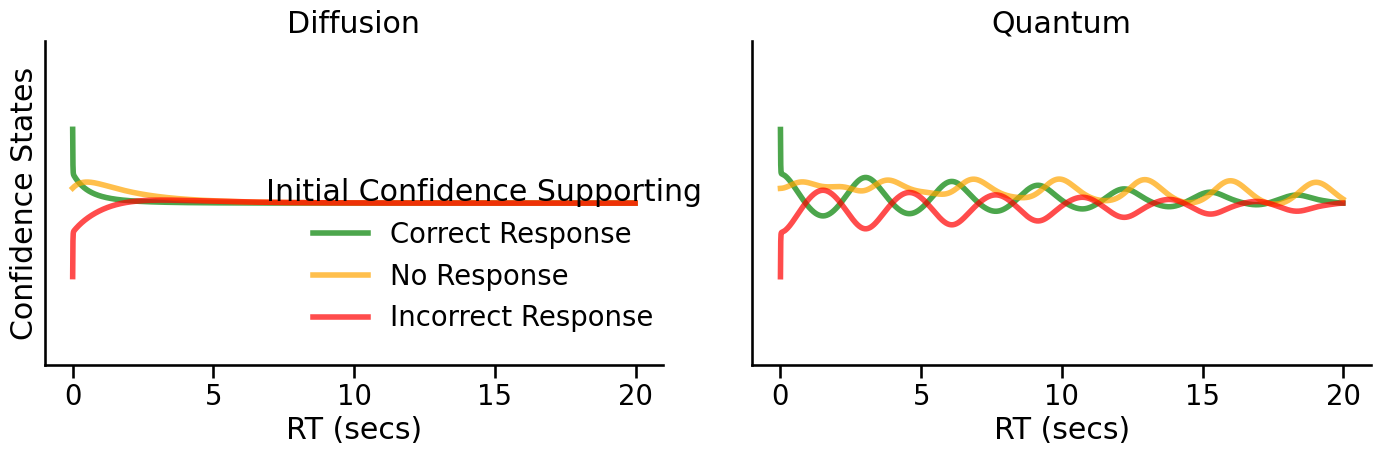

In [93]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_plot_internal1.query("(mu =='$v$=1, $\sigma$=2')").assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response"})),
                     x="time", y="value", 
                    col_order=["Diffusion", "Quantum"], hue = "prior", hue_order= ["Correct Response", "No Response" ,"Incorrect Response"],
                    palette=custom_color,
                    col="type", color="black", aspect=1.5, height=5, kind="line",lw=4, alpha=0.7, facet_kws={"sharey":False})
    f.legend.set_title("Initial Confidence Supporting")
    f.legend.set_bbox_to_anchor((0.39,0.4))
    f.set_titles("{col_name}")
    f.set_xlabels("RT (secs)")
    #f.axes[1,0].set_ylabel("CS (Quantum)")
    #f.axes[1,0].set_title("")
    #f.axes[1,1].set_title("")
    #f.axes[1,2].set_title("")
    #f.axes[1,3].set_title("")
    #f.axes[0,0].set_ylabel("CS (Diffusion)")
    f.set(yticks=[])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-5.5, 5.5))
    f.set_ylabels("Confidence States")


In [94]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

NameError: name 'm_Mn_i' is not defined

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i